# EMG Gesture Classification — Training Notebook

Run cells top to bottom. Do not skip cells.
No streamer or armband needed — works from saved CSVs in data/raw/.

---
## Cell 1 — Imports

In [2]:
import os
import sys
import glob
import numpy as np
import matplotlib.pyplot as plt

from libemg.feature_extractor import FeatureExtractor
from libemg.emg_predictor import EMGClassifier
from libemg.offline_metrics import OfflineMetrics
from libemg.utils import get_windows

print('Imports OK')

/Users/tobias.seidl/Desktop/Studium/Master/NUI/EMG Recognition/F_LibEMG-Gesture-Classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/tobias.seidl/Desktop/Studium/Master/NUI/EMG Recognition/F_LibEMG-Gesture-Classification/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Imports OK


---
## Cell 2 — Configuration

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if not os.path.isdir(os.path.join(PROJECT_ROOT, 'data')):
    PROJECT_ROOT = os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from scripts.gesture_config import GESTURE_NAMES

DATA_DIR      = os.path.join(PROJECT_ROOT, 'data', 'raw')
MODEL_DIR     = os.path.join(PROJECT_ROOT, 'models')
MODEL_PATH    = os.path.join(MODEL_DIR, 'clf')  # libemg .save() adds extension automatically

N_CLASSES     = len(GESTURE_NAMES)
SAMPLING_RATE = 500
WINDOW_SIZE   = 200
WINDOW_INC    = 100
FEATURE_GROUP = 'HTD'
CLASSIFIER    = 'LDA'  # Start with LDA — simple, fast, interpretable
N_TEST_REPS   = 2

print(f'Data directory : {DATA_DIR}')
print(f'Data dir exists: {os.path.isdir(DATA_DIR)}')
print(f'Window size    : {WINDOW_SIZE} samples ({WINDOW_SIZE/SAMPLING_RATE*1000:.0f} ms)')
print(f'Feature group  : {FEATURE_GROUP}')
print(f'Classifier     : {CLASSIFIER}')


Data directory : /Users/tobias.seidl/Desktop/Studium/Master/NUI/EMG Recognition/F_LibEMG-Gesture-Classification/data/raw
Data dir exists: True
Window size    : 200 samples (400 ms)
Feature group  : HTD
Classifier     : LDA


---
## Cell 3 — Load Data

In [4]:
all_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.csv'), recursive=True))

data_list    = []
classes_list = []
reps_list    = []

for f in all_files:
    parts          = f.replace('\\', '/').split('/')
    gesture_folder = [p for p in parts if p.startswith('gesture_')][0]
    rep_file       = [p for p in parts if p.startswith('rep_')][0]
    class_id       = int(gesture_folder.replace('gesture_', ''))
    rep_id         = int(rep_file.replace('rep_', '').replace('.csv', ''))
    arr            = np.loadtxt(f, delimiter=',', skiprows=1)
    data_list.append(arr)
    classes_list.append(class_id)
    reps_list.append(rep_id)

classes_arr = np.array(classes_list)
reps_arr    = np.array(reps_list)

print(f'Loaded {len(data_list)} files')
print(f'Shape of first file : {data_list[0].shape}  (samples x channels)')
print(f'Classes             : {np.unique(classes_arr)}')
print(f'Reps                : {np.unique(reps_arr)}')

Loaded 499 files
Shape of first file : (1495, 8)  (samples x channels)
Classes             : [0 1 2 3 4]
Reps                : [  0   1   2   3   4   5   6   7   8   9  10  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119]


---
## Cell 4 — Train / Test Split

In [5]:
# Hold out the last 2 reps per gesture for testing (more robust than 1)
test_reps  = sorted(np.unique(reps_arr))[-2:]  # e.g. [8, 9]
train_mask = ~np.isin(reps_arr, test_reps)
test_mask  = np.isin(reps_arr, test_reps)

train_data    = [data_list[i] for i in range(len(data_list)) if train_mask[i]]
train_classes = classes_arr[train_mask]

test_data    = [data_list[i] for i in range(len(data_list)) if test_mask[i]]
test_classes = classes_arr[test_mask]

print(f'Train: {len(train_data)} files, classes {np.unique(train_classes)}')
print(f'Test : {len(test_data)} files, classes {np.unique(test_classes)}')

Train: 489 files, classes [0 1 2 3 4]
Test : 10 files, classes [0 1 2 3 4]


---
## Cell 5 — Windowing

In [6]:
def make_windows_and_labels(data_list, classes_arr):
    all_windows = []
    all_labels  = []
    for i, arr in enumerate(data_list):
        # get_windows returns (n_windows, n_channels, window_size)
        wins = get_windows(arr, WINDOW_SIZE, WINDOW_INC)
        all_windows.append(wins)
        all_labels.extend([classes_arr[i]] * len(wins))
    windows = np.vstack(all_windows)
    labels  = np.array(all_labels)
    return windows, labels

train_windows, train_labels = make_windows_and_labels(train_data, train_classes)
test_windows,  test_labels  = make_windows_and_labels(test_data,  test_classes)

print(f'Train windows (raw) : {train_windows.shape}')
print(f'Test windows  (raw) : {test_windows.shape}')

# ── CRITICAL FIX: Remove DC offset per window ──
# The MindRove armband outputs raw ADC values with large DC offsets
# (values in range -5000 to -30000). Each recording session can have
# a different DC level. If we don't remove it, the classifier learns
# to distinguish the DC offsets (which vary per session) rather than
# the actual EMG waveform patterns.
#
# This MUST match what live_demo.py does at inference time.
# axis=2 = the time/sample axis in (n_windows, n_channels, window_size)

train_windows = train_windows - train_windows.mean(axis=2, keepdims=True)
test_windows  = test_windows  - test_windows.mean(axis=2, keepdims=True)

print(f'\nAfter DC offset removal:')
print(f'Train windows : {train_windows.shape}  (n_windows, n_channels, window_size)')
print(f'Test windows  : {test_windows.shape}')
print(f'Train mean ch0 (should be ~0): {train_windows[:, 0, :].mean():.4f}')
print(f'Train label counts: {dict(zip(*np.unique(train_labels, return_counts=True)))}')
print(f'Test label counts : {dict(zip(*np.unique(test_labels,  return_counts=True)))}')


Train windows (raw) : (6400, 8, 200)
Test windows  (raw) : (132, 8, 200)

After DC offset removal:
Train windows : (6400, 8, 200)  (n_windows, n_channels, window_size)
Test windows  : (132, 8, 200)
Train mean ch0 (should be ~0): 0.0000
Train label counts: {0: 1284, 1: 1283, 2: 1284, 3: 1282, 4: 1267}
Test label counts : {0: 27, 1: 26, 2: 27, 3: 26, 4: 26}


---
## Cell 6 — Feature Extraction

In [7]:
fe = FeatureExtractor()

train_features = fe.extract_feature_group(FEATURE_GROUP, train_windows)
test_features  = fe.extract_feature_group(FEATURE_GROUP, test_windows)

train_dataset = {
    'training_features': train_features,
    'training_labels'  : train_labels,
}

feature_matrix = np.hstack(list(train_features.values()))
print(f'Feature matrix shape (train) : {feature_matrix.shape}  (n_windows x n_features)')
print(f'Features per window          : {feature_matrix.shape[1]}')

Feature matrix shape (train) : (6400, 32)  (n_windows x n_features)
Features per window          : 32


---
## Cell 7 — Train Classifier

In [8]:
clf = EMGClassifier(CLASSIFIER)
clf.fit(train_dataset)
print(f'{CLASSIFIER} classifier trained.')

LDA classifier trained.


---
## Cell 8 — Evaluate

In [9]:
om = OfflineMetrics()

predictions, _ = clf.run(test_features)
true_labels    = test_labels

ca = om.get_CA(true_labels, predictions)
print(f'Classification Accuracy : {ca * 100:.1f}%')

cm = om.get_CONF_MAT(true_labels, predictions)
print(f'\nConfusion Matrix (rows=true, cols=predicted):')
print(f'Classes: {list(GESTURE_NAMES.values())}')
print(cm)

Classification Accuracy : 62.1%

Confusion Matrix (rows=true, cols=predicted):
Classes: ['Rest', 'Daumen hoch', 'Swipe', 'Handgelenk drehen', 'Zeigen/Tippen']
[[21.  4.  0.  2.  0.]
 [ 0. 25.  0.  1.  0.]
 [ 0.  0. 13. 14.  0.]
 [ 1.  2.  1. 22.  0.]
 [ 1.  1. 21.  2.  1.]]


---
## Cell 9 — Plot Confusion Matrix

Saved -> /Users/tobias.seidl/Desktop/Studium/Master/NUI/EMG Recognition/F_LibEMG-Gesture-Classification/models/confusion_matrix.png


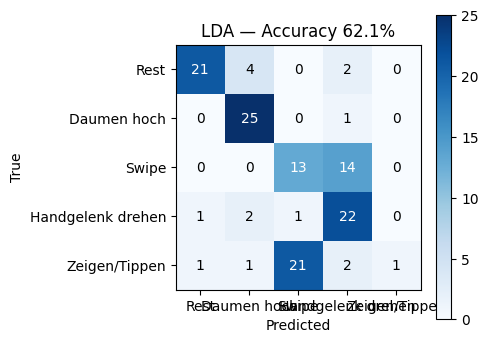

In [10]:
labels = list(GESTURE_NAMES.values())
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{CLASSIFIER} — Accuracy {ca*100:.1f}%')
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, str(int(cm[i, j])), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
os.makedirs(MODEL_DIR, exist_ok=True)
save_path = os.path.join(MODEL_DIR, 'confusion_matrix.png')
plt.savefig(save_path, dpi=150)
print(f'Saved -> {save_path}')
plt.show()

---
## Cell 10 — Save Model

In [11]:
os.makedirs(MODEL_DIR, exist_ok=True)
clf.save(MODEL_PATH)  # saves to models/clf (libemg handles the extension)
print(f'Model saved -> {MODEL_PATH}')
print('Ready for live_demo.py')


Model saved -> /Users/tobias.seidl/Desktop/Studium/Master/NUI/EMG Recognition/F_LibEMG-Gesture-Classification/models/clf
Ready for live_demo.py


---
## (Optional) Cell 11 — Try a Different Classifier

Change `model` to any of: `'SVM'`, `'KNN'`, `'RF'`, `'MLP'`

In [1]:
model = 'KNN'
clf_alt = EMGClassifier(model)
clf_alt.fit(train_dataset)
preds_alt, _ = clf_alt.run(test_features)
ca_alt = om.get_CA(true_labels, preds_alt)
print(f'{model} accuracy : {ca_alt * 100:.1f}%')
print(f'{CLASSIFIER} accuracy  : {ca * 100:.1f}%')

# If you want to use this model instead, uncomment:
# clf_alt.save(MODEL_PATH)
# print(f'Saved {model} model -> {MODEL_PATH}')


NameError: name 'EMGClassifier' is not defined